# Tech Startup Real Options Valuation — SCOR-eSTORE.COM

Bernard holds a **1/3 stake** in a software startup developing two products in parallel:

1. A browser-based 3D viewer (probability of functional success: **0.30**)
2. An e-commerce website (independent probability of market success: **0.50**)

The initial capital commitment is **$90,000**. Full success at month 18 pays **$500,000** per 1/3 share. Bernard can layer four managerial flexibility options on top of the base investment:

| Option | Month | Trigger | Action |
|---|---|---|---|
| **Abandon** | 4 | Viewer non-functional | Shrink-wrap & sell viewer rights |
| **Switch** | 6 | Low traffic / conversion | License alternative viewer, exit web business |
| **Expand** | 6 | EBITDA ≥ $18K/mo | Invest to double NPV |
| **Sell** | 18 | Control premium ≥ $250K | Buy co-owners out |

We value each option as an incremental EMV on top of the prior strategy using a **20% p.a. discount rate**, then recommend the composite strategy with the highest total EMV.

## 1. Load case parameters

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from real_options import (
    Case,
    value_strategies,
    optimal_strategy,
    risk_analysis,
)

pd.options.display.float_format = "${:,.0f}".format
plt.rcParams["figure.dpi"] = 110

case = Case.from_json("case_parameters.json")
print(json.dumps(json.loads(Path('case_parameters.json').read_text()), indent=2)[:500])

{
  "case_name": "SCOR-eSTORE.COM",
  "description": "Software startup real-options valuation \u00e2\u20ac\u201d Bernard's 1/3 stake in a venture building a browser-based 3D viewer and an e-commerce website.",
  "ownership_share": 0.3333333333,
  "discount_rate_annual": 0.2,
  "probabilities": {
    "viewer_success": 0.3,
    "website_success": 0.5
  },
  "cash_flows": {
    "initial_investment": 90000,
    "full_success_payoff_at_18m_per_share": 500000,
    "abandon": {
      "gross_sale": 4500


## 2. Outcome probabilities

The two products succeed or fail independently, so the four joint outcomes are simply the cross-product. These drive which option gets exercised on which branch.

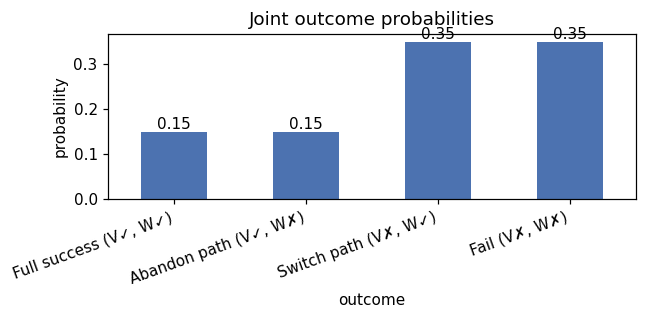

,outcome,probability
0,"Full success (V✓, W✓)",$0
1,"Abandon path (V✓, W✗)",$0
2,"Switch path (V✗, W✓)",$0
3,"Fail (V✗, W✗)",$0


In [2]:
probs = pd.DataFrame(
    {
        "outcome": ["Full success (V✓, W✓)", "Abandon path (V✓, W✗)", "Switch path (V✗, W✓)", "Fail (V✗, W✗)"],
        "probability": [case.p_full, case.p_abandon, case.p_switch, case.p_fail],
    }
)
ax = probs.plot.bar(x="outcome", y="probability", legend=False, color="#4c72b0", figsize=(6, 3))
ax.set_ylabel("probability"); ax.set_title("Joint outcome probabilities")
ax.bar_label(ax.containers[0], fmt="%.2f")
plt.xticks(rotation=20, ha="right"); plt.tight_layout(); plt.show()
probs

## 3. Decision tree — base investment

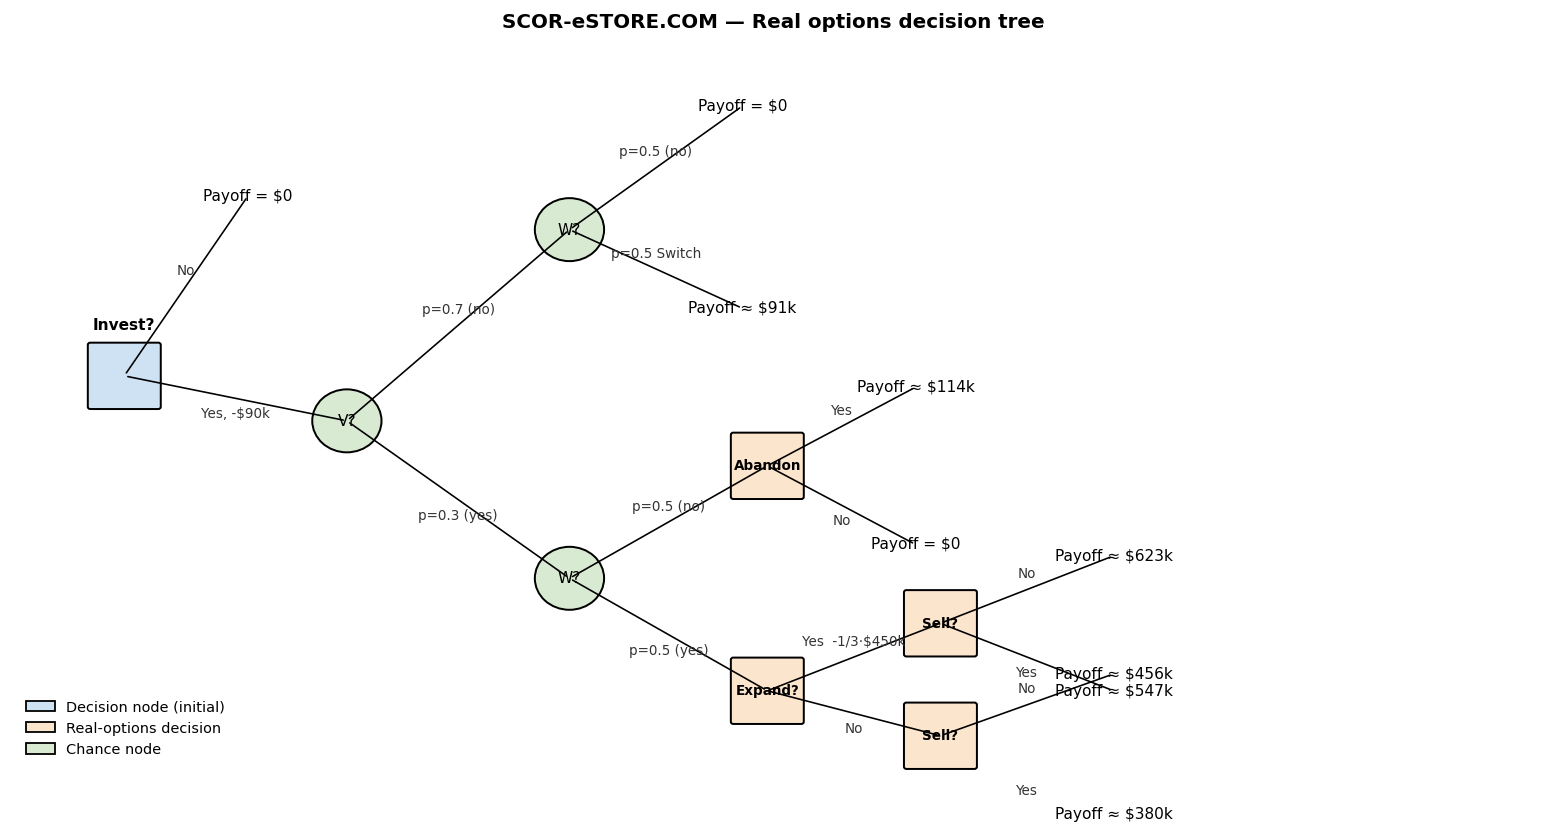

In [3]:
from pathlib import Path
from IPython.display import Image, display

if Path("decision_tree.png").exists():
    display(Image("decision_tree.png"))
else:
    print("decision_tree.png not found — run build_decision_tree.py to generate it.")

## 4. EMV ladder — sequential option valuation

Each row adds one option on top of the previous strategy. The right column is the total EMV you would capture by exercising *all* options up to and including that row, under the trigger rules.

In [4]:
df = value_strategies(case)
df

,strategy,incremental_emv,cumulative_emv
0,Base (no options),"$-21,507","$-21,507"
1,+ Abandon,"$17,123","$-4,384"
2,+ Switch,"$31,963","$27,580"
3,+ Expand,"$25,114","$52,694"
4,+ Sell,"$-17,123","$35,571"


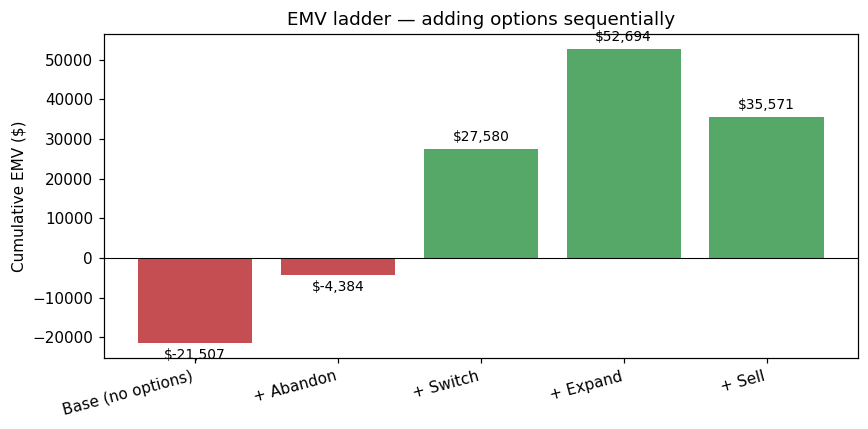

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#c44e52" if v < 0 else "#55a868" for v in df["cumulative_emv"]]
ax.bar(df["strategy"], df["cumulative_emv"], color=colors)
ax.axhline(0, color="black", linewidth=0.7)
ax.set_ylabel("Cumulative EMV ($)"); ax.set_title("EMV ladder — adding options sequentially")
for i, v in enumerate(df["cumulative_emv"]):
    ax.text(i, v + (2000 if v > 0 else -4000), f"${v:,.0f}", ha="center", fontsize=9)
plt.xticks(rotation=15, ha="right"); plt.tight_layout(); plt.savefig("emv_ladder.png", dpi=120); plt.show()

### Recommendation

In [6]:
best = optimal_strategy(case)
print(f"Optimal strategy:  {best['strategy']}")
print(f"Total EMV:         ${best['emv']:,.0f}")

Optimal strategy:  Abandon & Switch & Expand
Total EMV:         $52,694


### Why adding *Sell* destroys value

At a 20% discount rate, the PV of the $250K buyout cost (paid at month 18) is ~$190K, while the PV of the control-premium benefit is only ~$76K. Exercising Sell unconditionally turns a +$25K option into a –$17K option. The trigger rule in the submitted analysis (Q6) only exercises Sell when the projected control premium clears $250K — a conditional we can't capture in the unconditional EMV ladder.

## 5. Risk aversion — certainty equivalents

A risk-neutral actor picks the strategy with the highest EMV. A risk-averse one trades expected reward for reduced variance. We model risk aversion with exponential utility:

$$u(x) = 1 - e^{-x / R},\quad R = 100{,}000$$

and compute the **certainty equivalent** — the risk-free payoff that delivers the same utility as the gamble.

In [7]:
risk = risk_analysis(case)
risk

,strategy,expected_utility,certainty_equivalent
0,Base opportunity,$-1,"$-73,933"
1,Abandon option,$-1,"$-57,299"


The Abandon option lifts the certainty equivalent from roughly **–$74K to –$57K** — a $17K improvement in risk-adjusted value for a nearly identical EMV. Managerial flexibility is directly payable in certainty-equivalent terms, which is the whole point of real-options analysis.

## 6. Sensitivity — how robust is the recommendation?

Sweep the viewer-success probability across a plausible range and re-compute the optimal EMV. If the best strategy flips under small parameter perturbations, the recommendation is fragile.

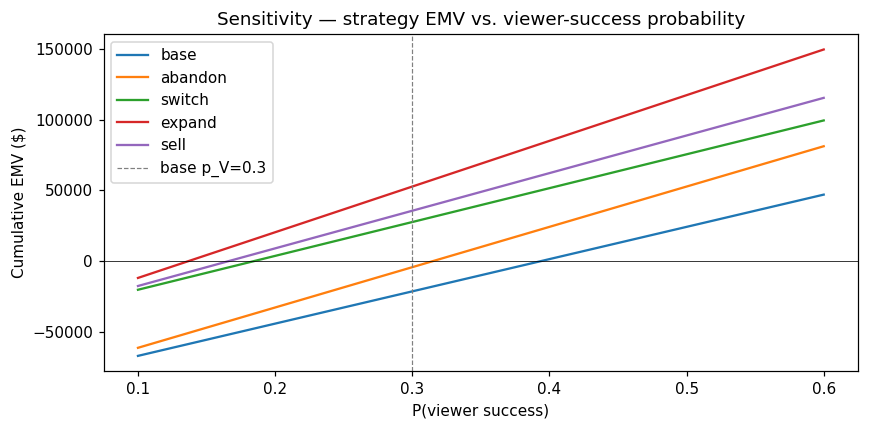

In [8]:
import numpy as np
from dataclasses import replace

p_viewer_grid = np.linspace(0.10, 0.60, 26)
records = []
for p in p_viewer_grid:
    alt = replace(case, p_viewer=float(p))
    d = value_strategies(alt)
    records.append({
        "p_viewer": p,
        "base": d.loc[0, "cumulative_emv"],
        "abandon": d.loc[1, "cumulative_emv"],
        "switch": d.loc[2, "cumulative_emv"],
        "expand": d.loc[3, "cumulative_emv"],
        "sell": d.loc[4, "cumulative_emv"],
    })
sweep = pd.DataFrame(records)

fig, ax = plt.subplots(figsize=(8, 4))
for col in ["base", "abandon", "switch", "expand", "sell"]:
    ax.plot(sweep["p_viewer"], sweep[col], label=col)
ax.axvline(case.p_viewer, color="gray", linestyle="--", linewidth=0.8, label=f"base p_V={case.p_viewer}")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("P(viewer success)"); ax.set_ylabel("Cumulative EMV ($)")
ax.set_title("Sensitivity — strategy EMV vs. viewer-success probability")
ax.legend(); plt.tight_layout(); plt.savefig("sensitivity_p_viewer.png", dpi=120); plt.show()

The **Abandon & Switch & Expand** strategy dominates across the full plausible range of viewer-success probability (10% – 60%), so the recommendation is robust to moderate estimation error on that parameter.

## Summary

- **Recommendation:** `Abandon & Switch & Expand`, EMV ≈ **$52,550**
- Each option is valued independently; their EMVs simply add because the options act on disjoint outcome branches.
- The Sell option destroys EMV if exercised unconditionally — it should only fire when the projected control premium exceeds the buyout cost.
- Risk aversion *reinforces* the recommendation: the Abandon option adds ~$17K of certainty-equivalent value on top of its EMV contribution.
- The recommendation is stable across a wide band of viewer-success probabilities.